In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

import sys
sys.path.append("..")  
from utils import pull_data_from_yfinance

### Read data
6 tickers, 1 year ago from 1 Feb 2026



In [2]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA']
start_date = datetime(2026, 2, 1) - timedelta(days=365)
end_date = datetime(2026, 2, 1)

# store data in a dictionary and flatten the ticket row
data = pull_data_from_yfinance(tickers, start_date, end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
data['AAPL'].head()

,Date,Close,High,Low,Open,Volume
0,2025-02-03,226.562469,230.358225,224.267137,228.529910,73063300
1,2025-02-04,231.322067,231.649974,225.211102,225.807299,45067300
2,2025-02-05,230.994156,231.192883,226.820823,227.079167,39620300
3,2025-02-06,231.739395,232.315715,228.967099,229.821640,29925300
4,2025-02-07,226.184891,232.514446,225.817229,231.123340,39707200


### Data Visualisation

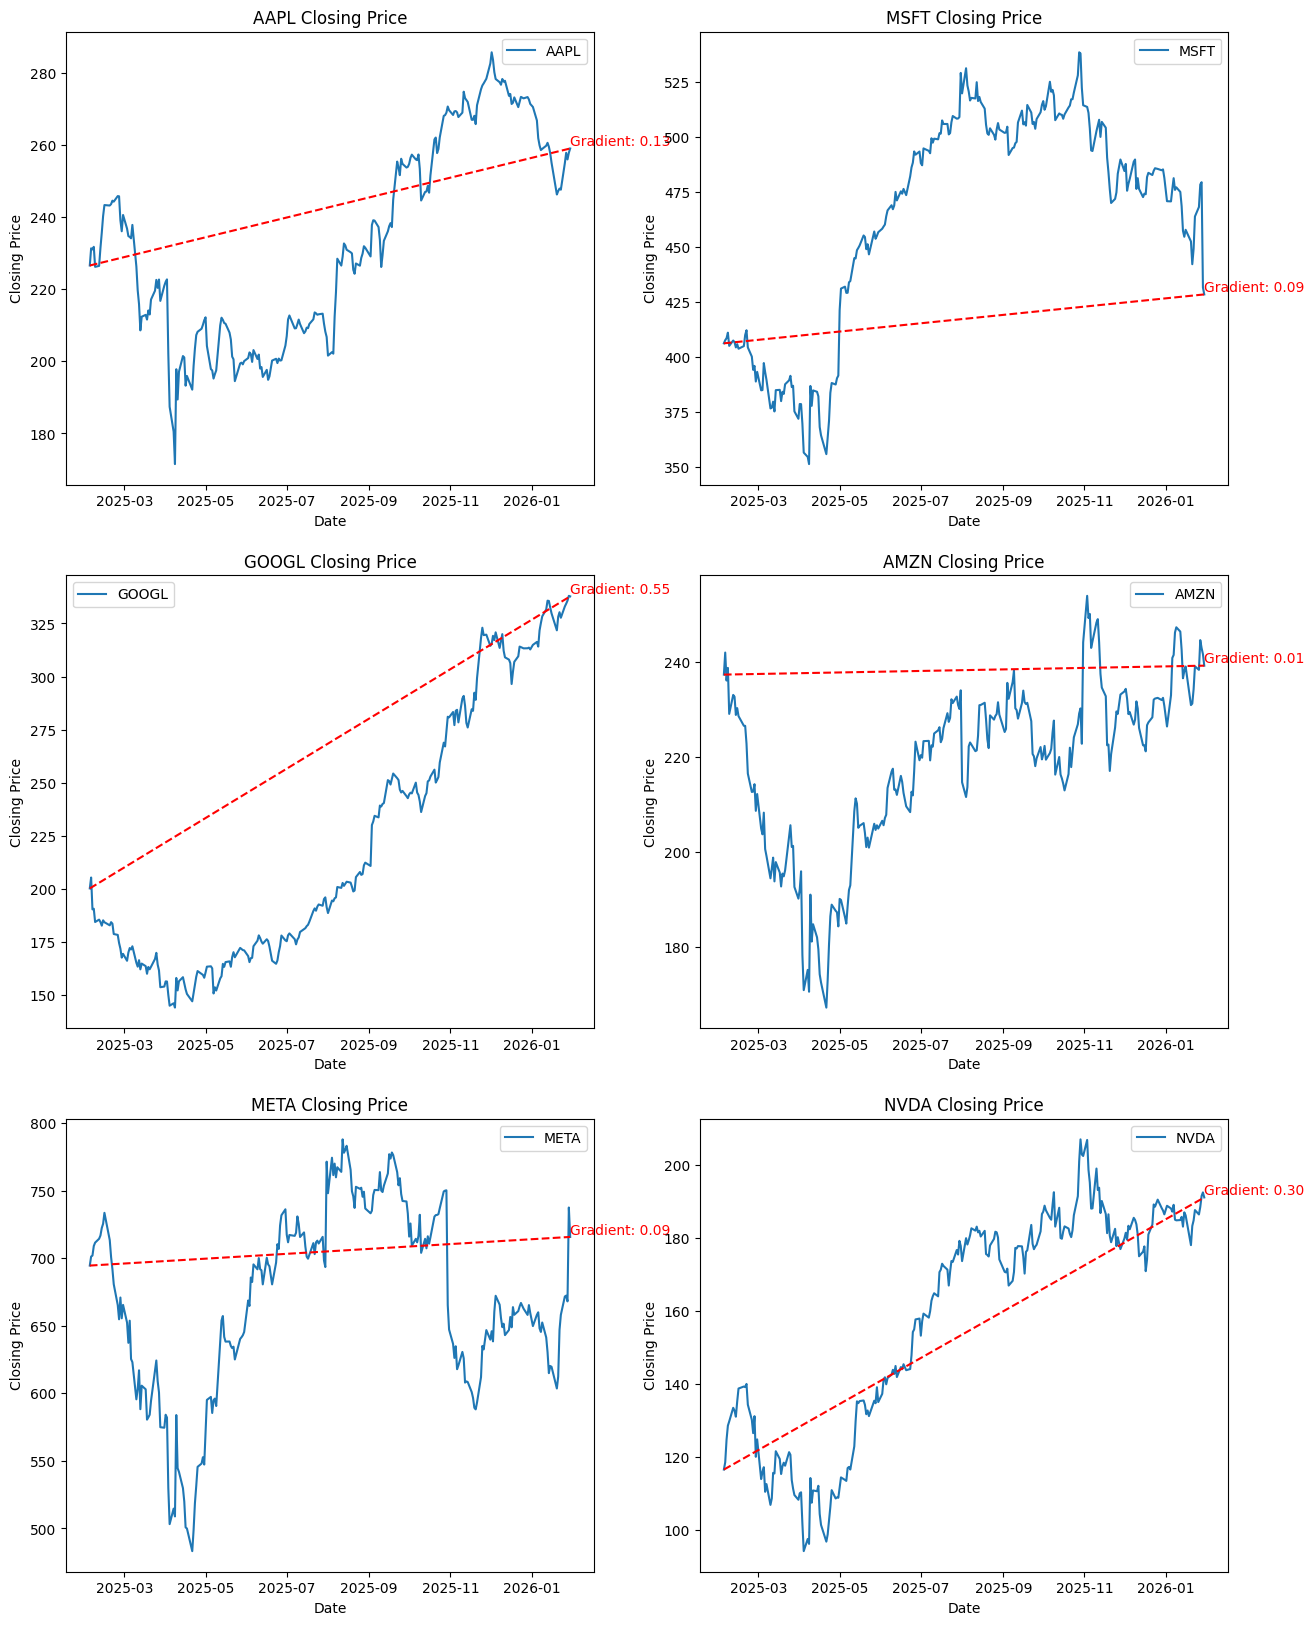

In [4]:
### Visualise the closing price of each stock over the past year in multi figure plots, with each plot showing the closing price of one stock
### Connect the start and end points of the closing price with a line to show the overall trend
### Indicating the gradient of the line at the side of the dotted line
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))
axes = axes.flatten()
gradients = {}
for i, ticker in enumerate(tickers):    
    axes[i].plot(data[ticker]['Date'], data[ticker]['Close'], label=ticker)
    axes[i].set_title(f"{ticker} Closing Price")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Closing Price")
    axes[i].legend()
    
    # Connect the start and end points of the closing price with a line to show the overall trend
    start_price = data[ticker]['Close'][0]
    end_price = data[ticker]['Close'][len(data[ticker]['Close']) - 1]
    axes[i].plot([data[ticker]['Date'][0], data[ticker]['Date'][len(data[ticker]['Date']) - 1]], [start_price, end_price], 'r--')
    
    # Calculate the gradient of the line and indicate it at the side of the dotted line
    gradient = (end_price - start_price) / (len(data[ticker]['Date']) - 1)
    gradients[ticker] = gradient
    axes[i].text(data[ticker]['Date'][len(data[ticker]['Date']) - 1], end_price, f"Gradient: {gradient:.2f}", color='red', verticalalignment='bottom')

# Price Momentum

Let $t$ denote time measured in units of **1 month**, with $t = 0$ corresponding to the most recent time. Let $P_i(t)$ be the time series of prices (fully adjusted for splits and dividends) for the stock labeled by $i$ ($i = 1, \dots, N$, where $N$ is the number of stocks in the trading universe).

**Monthly return**

$$R_i(t) = \frac{P_i(t)}{P_i(t+1)} - 1 \tag{266}$$

**Cumulative return** over the $T$-month *formation period* (usually $T = 12$), skipping the most recent $S$-month *skip period* (usually $S = 1$):

$$R_i^{\text{cum}} = \frac{P_i(S)}{P_i(S+T)} - 1 \tag{267}$$

**Mean monthly return** over the formation period:

$$R_i^{\text{mean}} = \frac{1}{T} \sum_{t=S}^{S+T-1} R_i(t) \tag{268}$$

**Risk-adjusted mean return** over the formation period:

$$R_i^{\text{risk.adj}} = \frac{R_i^{\text{mean}}}{\sigma_i} \tag{269}$$

**Monthly volatility** over the formation period:

$$\sigma_i^2 = \frac{1}{T-1} \sum_{t=S}^{S+T-1} \left( R_i(t) - R_i^{\text{mean}} \right)^2 \tag{270}$$

Here: $R_i(t)$ is the monthly return; $R_i^{\text{cum}}$ is the cumulative return computed over the $T$-month formation period (usually $T = 12$) skipping the most recent $S$-month skip period (usually $S = 1$); $R_i^{\text{mean}}$ is the mean monthly return computed over the formation period; $R_i^{\text{risk.adj}}$ is the risk-adjusted mean return over the formation period; and $\sigma_i$ is the monthly volatility calculated over the formation period.

In [5]:
### Calculate the 1 year cumulative returns for each stock
cumulative_returns = {}
for ticker in tickers:
    cumulative_returns[ticker] = (data[ticker]['Close'][len(data[ticker]['Close']) - 1] - data[ticker]['Close'][0]) / data[ticker]['Close'][0]

### Sort the cumulative returns in descending order
cumulative_returns = dict(sorted(cumulative_returns.items(), key=lambda item: item[1], reverse=True))
print("1 Year Cumulative Returns:")
for ticker, ret in cumulative_returns.items():
    print(f"{ticker}: {ret:.2f}")

1 Year Cumulative Returns:
GOOGL: 0.69
NVDA: 0.64
AAPL: 0.14
MSFT: 0.05
META: 0.03
AMZN: 0.01


### Strategy 1
Suppose we hold a long only portfolio, we long the stock that has >=50% cumulative returns and observe the PnL if we vary the holding period

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


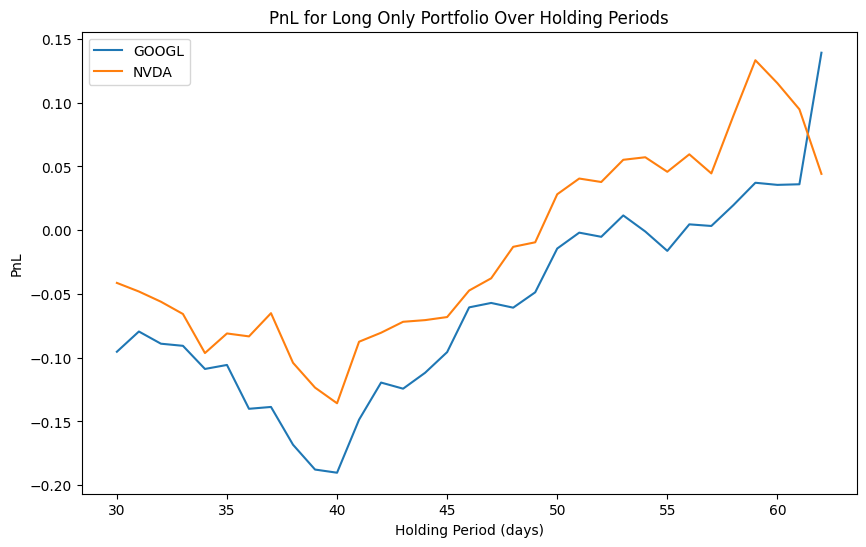

In [6]:
### Hold a long only portfolio of the stocks that have >=50% cumulative returns over the past year, and calculate the realized PnL percentage if we vary the holding period from 1 month to 3 months, and plot the PnL for each stock over the holding periods
### we need the historical data for the next 3 months after 1 Feb 2026 to calculate the PnL for the holding periods

holding_periods = [i for i in range(30, 91)]  # in days
pnl = {ticker: [] for ticker in tickers if cumulative_returns[ticker] >= 0.5}
future_data = pull_data_from_yfinance(list(pnl.keys()), start_date=datetime(2026, 2, 1), end_date=datetime(2026, 5, 1))
for ticker in pnl.keys():
    for period in holding_periods:
        if len(future_data[ticker]['Close']) >= period:
            buy_price = data[ticker]['Close'][len(data[ticker]['Close']) - 1]
            sell_price = future_data[ticker]['Close'][period - 1]
            pnl[ticker].append((sell_price - buy_price) / buy_price)
        else:
            pnl[ticker].append(np.nan)  # Not enough data to calculate PnL for this period

### Plot the PnL for each stock over the holding periods
fig, ax = plt.subplots(figsize=(10, 6))
for ticker, pnl_values in pnl.items():
    ax.plot(holding_periods, pnl_values, label=ticker)
ax.set_title("PnL for Long Only Portfolio Over Holding Periods")
ax.set_xlabel("Holding Period (days)")
ax.set_ylabel("PnL")
ax.legend()
plt.show()


6 Months Cumulative Returns:
GOOGL: 78.99%
AAPL: 28.48%
AMZN: 11.43%
NVDA: 10.03%
META: -4.33%
MSFT: -17.61%


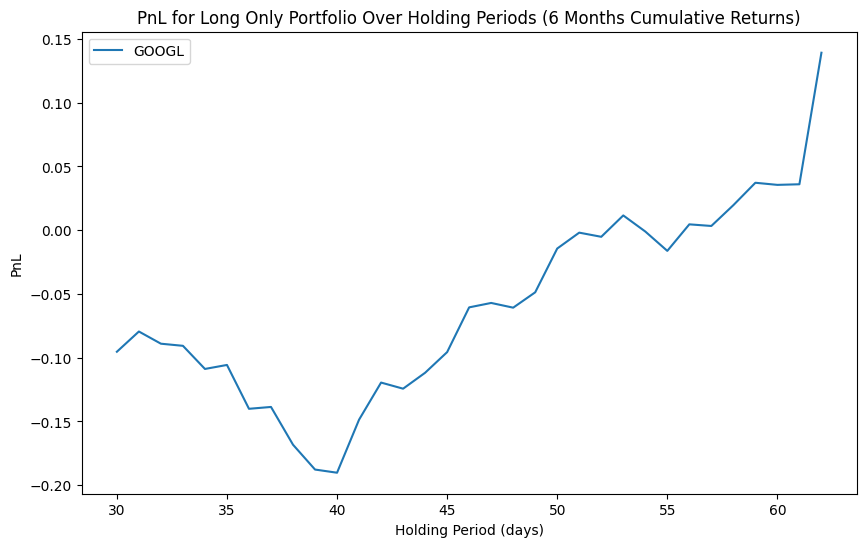

In [7]:
### Suppose we vary the cumulative returns window from 12 months to 6 months, how would the PnL change for the long only portfolio? Calculate the cumulative returns for each stock over the past 6 months and repeat the above steps to calculate and plot the PnL for the stocks that have >=50% cumulative returns over the past 6 months. Compare the PnL with the previous 12 month cumulative returns window.
from cumulative_returns import calculate_cumulative_return_for_multiple_tickers
six_months_returns = calculate_cumulative_return_for_multiple_tickers(data, tickers, months=6)
print("6 Months Cumulative Returns:")
for ticker, ret in six_months_returns.items():
    print(f"{ticker}: {ret:.2%}")

six_months_pnl = {ticker: [] for ticker in tickers if six_months_returns[ticker] >= 0.5}
for ticker in six_months_pnl.keys():
    for period in holding_periods:
        if len(future_data[ticker]['Close']) >= period:
            buy_price = data[ticker]['Close'][len(data[ticker]['Close']) - 1]
            sell_price = future_data[ticker]['Close'][period - 1]
            six_months_pnl[ticker].append((sell_price - buy_price) / buy_price)
        else:
            six_months_pnl[ticker].append(np.nan)  # Not enough data to calculate PnL for this period
fig, ax = plt.subplots(figsize=(10, 6))
for ticker, pnl_values in six_months_pnl.items():
    ax.plot(holding_periods, pnl_values, label=ticker)
ax.set_title("PnL for Long Only Portfolio Over Holding Periods (6 Months Cumulative Returns)")
ax.set_xlabel("Holding Period (days)")
ax.set_ylabel("PnL")
ax.legend()
plt.show()  

### Strategy 2
Lets look at the mean monthly return and risk adjusted returns over the 12 months formation period

In [8]:
# Mean monthly return over the formation period, computed on MONTH-END closes
# per Eq. (266)/(268) -- NOT on adjacent daily closes. We skip the most recent
# S=1 month (Eq. 267's skip period) to avoid short-term reversal.
from momentum import mean_monthly_return, risk_adjusted_return

T, S = 12, 1
# Need T monthly returns + the S skipped months + 1 base price => ~T+S+1 month-ends.
formation_start = datetime(2026, 2, 1) - timedelta(days=31 * (T + S + 1))
formation_data = pull_data_from_yfinance(tickers, start_date=formation_start, end_date=datetime(2026, 2, 1))

mean_returns = {ticker: mean_monthly_return(formation_data[ticker], T=T, S=S) for ticker in tickers}
print(f"Mean Monthly Return over formation period (T={T}, S={S}):")
for ticker, mean_ret in sorted(mean_returns.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{ticker}: {mean_ret:.2%}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Mean Monthly Return over formation period (T=12, S=1):
GOOGL: 4.77%
NVDA: 3.39%
META: 1.52%
MSFT: 1.41%
AAPL: 0.91%
AMZN: 0.71%


In [9]:
# Risk-adjusted mean return (Eq. 269): mean monthly return / monthly volatility,
# both measured over the same T-month formation period.
risk_adjusted_returns = {
    ticker: risk_adjusted_return(formation_data[ticker], T=T, S=S) for ticker in tickers
}
risk_adjusted_returns = dict(
    sorted(risk_adjusted_returns.items(), key=lambda item: item[1], reverse=True)
)
print(f"Risk Adjusted Returns (T={T}, S={S}):")
for ticker, risk_adj_ret in risk_adjusted_returns.items():
    print(f"{ticker}: {risk_adj_ret:.3f}")

Risk Adjusted Returns (T=12, S=1):
GOOGL: 0.483
NVDA: 0.290
MSFT: 0.209
META: 0.145
AAPL: 0.143
AMZN: 0.090


[*********************100%***********************]  1 of 1 completed


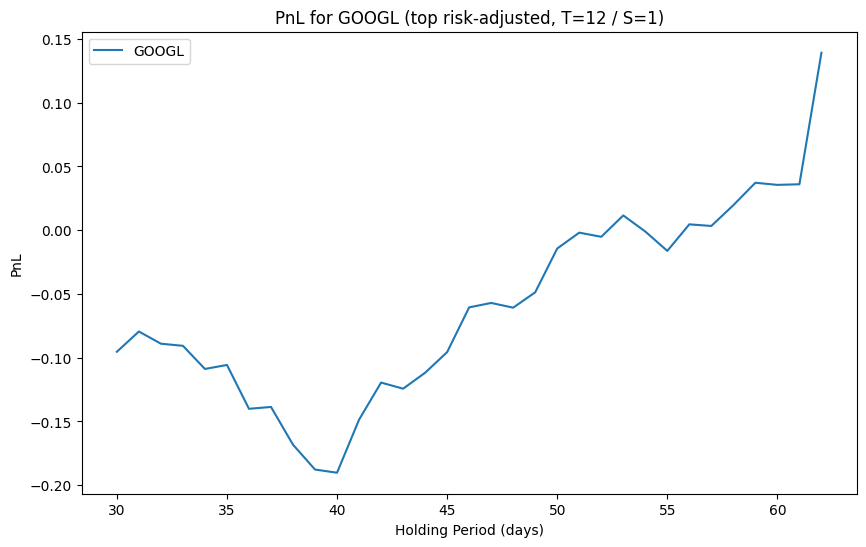

In [10]:
# Long the top risk-adjusted name and observe realized PnL over the holding period.
# With the corrected (monthly, skip-1) signal this is GOOGL rather than META.
ticker = list(risk_adjusted_returns.keys())[0]
top_pnl = []
future_data = pull_data_from_yfinance([ticker], start_date=datetime(2026, 2, 1), end_date=datetime(2026, 5, 1))
for period in holding_periods:
    if len(future_data[ticker]['Close']) >= period:
        buy_price = data[ticker]['Close'][len(data[ticker]['Close']) - 1]
        sell_price = future_data[ticker]['Close'][period - 1]
        top_pnl.append((sell_price - buy_price) / buy_price)
    else:
        top_pnl.append(np.nan)  # Not enough data to calculate PnL for this period
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(holding_periods, top_pnl, label=ticker)
ax.set_title(f"PnL for {ticker} (top risk-adjusted, T=12 / S=1)")
ax.set_xlabel("Holding Period (days)")
ax.set_ylabel("PnL")
ax.legend()
plt.show()

### Strategy 3